In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('cybersecurity_network_logs.csv')
df

,Protocol,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious
0,TCP,805,59,0,1169,0
1,TCP,926,58,0,379,0
2,TCP,974,3,0,79,0
3,ICMP,6121,16,0,1044,1
4,TCP,119,64,1,788,0
...,...,...,...,...,...,...
24995,UDP,1353,47,0,194,0
24996,UDP,368,93,1,433,0
24997,TCP,206,23,0,233,0
24998,TCP,501,23,0,738,0


In [3]:
df.head()

,Protocol,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious
0,TCP,805,59,0,1169,0
1,TCP,926,58,0,379,0
2,TCP,974,3,0,79,0
3,ICMP,6121,16,0,1044,1
4,TCP,119,64,1,788,0


In [4]:
df.tail()

,Protocol,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious
24995,UDP,1353,47,0,194,0
24996,UDP,368,93,1,433,0
24997,TCP,206,23,0,233,0
24998,TCP,501,23,0,738,0
24999,UDP,852,19,0,598,0


In [5]:
df.isnull().sum()

Protocol                  0
Packet_Size_Bytes         0
Connection_Duration_ms    0
Failed_Logins             0
Geo_Distance_km           0
Is_Malicious              0
dtype: int64

In [6]:
df.describe()

,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000
mean,647.35788,99.912200,0.279480,641.442120,0.049880
std,1012.79147,99.374995,1.136091,981.653985,0.217701
min,0.00000,0.000000,0.000000,0.000000,0.000000
25%,148.00000,29.000000,0.000000,149.000000,0.000000
50%,357.00000,69.000000,0.000000,359.000000,0.000000
75%,736.00000,138.000000,0.000000,741.000000,0.000000
max,10032.00000,1213.000000,16.000000,8661.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Protocol', 'Packet_Size_Bytes', 'Connection_Duration_ms',
       'Failed_Logins', 'Geo_Distance_km', 'Is_Malicious'],
      dtype='object')

In [9]:
df.describe

<bound method NDFrame.describe of       Protocol  Packet_Size_Bytes  Connection_Duration_ms  Failed_Logins  \
0          TCP                805                      59              0   
1          TCP                926                      58              0   
2          TCP                974                       3              0   
3         ICMP               6121                      16              0   
4          TCP                119                      64              1   
...        ...                ...                     ...            ...   
24995      UDP               1353                      47              0   
24996      UDP                368                      93              1   
24997      TCP                206                      23              0   
24998      TCP                501                      23              0   
24999      UDP                852                      19              0   

       Geo_Distance_km  Is_Malicious  
0             

In [10]:
print("Duplicated Row",df.duplicated().sum())

Duplicated Row 0


In [11]:
encoder=LabelEncoder()
df['scaled_Protocol']=encoder.fit_transform(df['Protocol'])
df

,Protocol,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious,scaled_Protocol
0,TCP,805,59,0,1169,0,1
1,TCP,926,58,0,379,0,1
2,TCP,974,3,0,79,0,1
3,ICMP,6121,16,0,1044,1,0
4,TCP,119,64,1,788,0,1
...,...,...,...,...,...,...,...
24995,UDP,1353,47,0,194,0,2
24996,UDP,368,93,1,433,0,2
24997,TCP,206,23,0,233,0,1
24998,TCP,501,23,0,738,0,1


In [12]:
data=df.drop('Protocol',axis=1)

In [13]:
data

,Packet_Size_Bytes,Connection_Duration_ms,Failed_Logins,Geo_Distance_km,Is_Malicious,scaled_Protocol
0,805,59,0,1169,0,1
1,926,58,0,379,0,1
2,974,3,0,79,0,1
3,6121,16,0,1044,1,0
4,119,64,1,788,0,1
...,...,...,...,...,...,...
24995,1353,47,0,194,0,2
24996,368,93,1,433,0,2
24997,206,23,0,233,0,1
24998,501,23,0,738,0,1


In [14]:
x=data[['scaled_Protocol','Packet_Size_Bytes','Connection_Duration_ms','Failed_Logins','Geo_Distance_km']]
y=data[['Is_Malicious']]

In [15]:
x_train,x_test,y_train,y_test=(train_test_split(x,y,test_size=0.2,random_state=40))

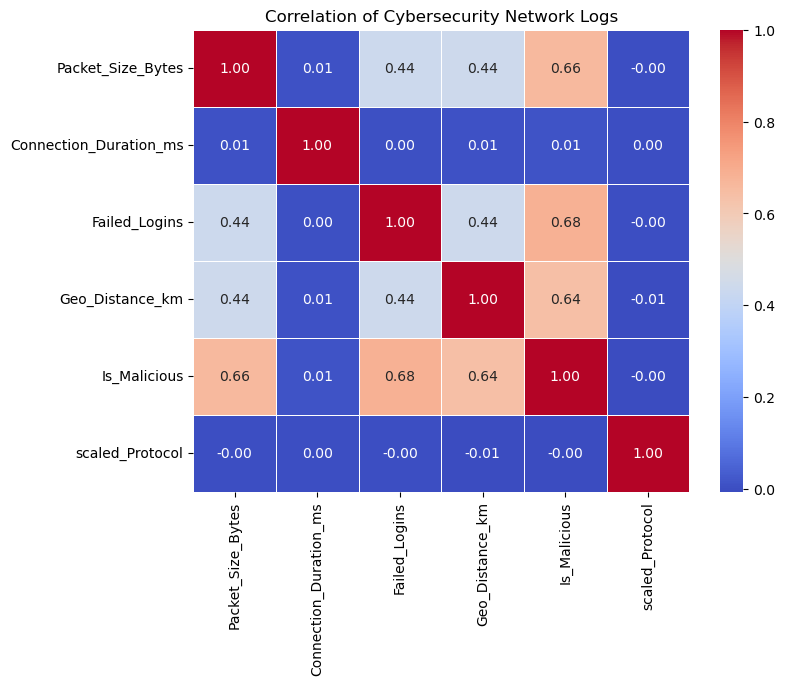

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
corr = data.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation of Cybersecurity Network Logs")
plt.show()

# Logistic Regression

In [17]:
lr=LogisticRegression(random_state=42)
lr.fit(x_train,y_train)

C:\Users\kenus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\kenus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred=lr.predict(x_test)

In [19]:
lr_accuracy=accuracy_score(y_test,y_pred)
print("Accuracy is: ",lr_accuracy)

Accuracy is:  0.992


In [20]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4747
           1       0.96      0.88      0.92       253

    accuracy                           0.99      5000
   macro avg       0.98      0.94      0.96      5000
weighted avg       0.99      0.99      0.99      5000



In [21]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[4737   10]
 [  30  223]]


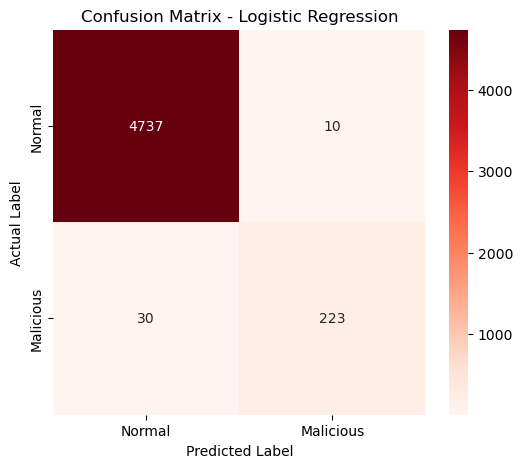

In [22]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Normal', 'Malicious'],
    yticklabels=['Normal', 'Malicious']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

# Decision Tree

In [23]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred=dt.predict(x_test)


In [25]:
dt_accuracy=accuracy_score(y_test,y_pred)
print("Accuracy is: ",dt_accuracy)

Accuracy is:  0.9902


In [26]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4747
           1       0.90      0.91      0.90       253

    accuracy                           0.99      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.99      0.99      0.99      5000



In [27]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[4721,   26],
       [  23,  230]])

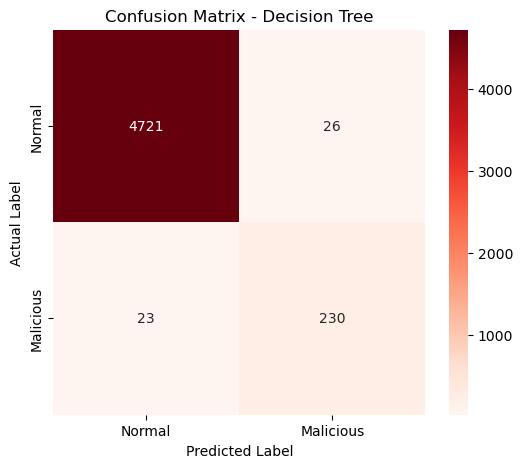

In [28]:


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Normal', 'Malicious'],
    yticklabels=['Normal', 'Malicious']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

# Random Forest

In [29]:
rf=RandomForestClassifier(random_state=42,n_estimators=100)


In [30]:
rf.fit(x_train,y_train)

C:\Users\kenus\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred=rf.predict(x_test)

In [32]:
rf_accuracy=accuracy_score(y_test,y_pred)
print("Accuracy is: ",rf_accuracy)

Accuracy is:  0.994


In [33]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4747
           1       0.97      0.91      0.94       253

    accuracy                           0.99      5000
   macro avg       0.98      0.96      0.97      5000
weighted avg       0.99      0.99      0.99      5000



In [34]:
rcm=confusion_matrix(y_test,y_pred)
rcm

array([[4739,    8],
       [  22,  231]])

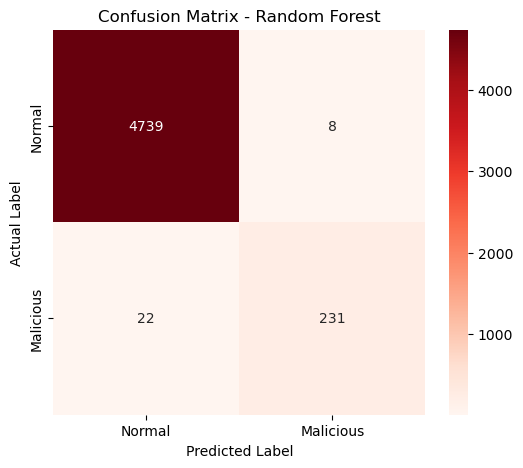

In [35]:


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Normal', 'Malicious'],
    yticklabels=['Normal', 'Malicious']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [36]:
# 3 models Accuracy Difference 

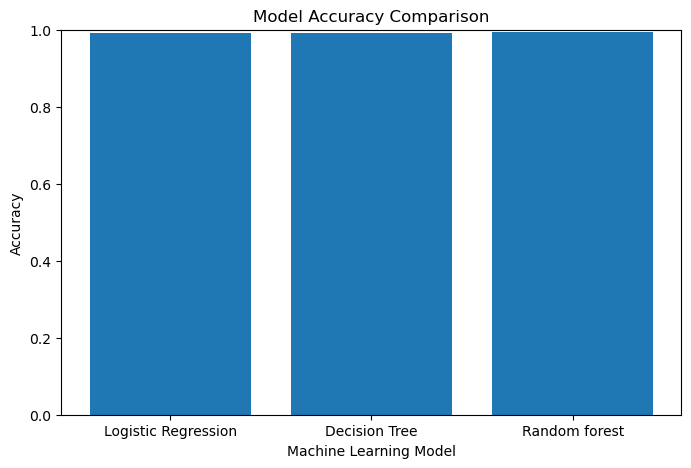

In [37]:
models = ['Logistic Regression', 'Decision Tree', 'Random forest']

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)

plt.show()

In [38]:
# !pip install gradio

In [39]:
def predict_malicious(protocol, packet_size, duration, failed_logins, geo_distance):

    # Convert protocol to the same encoded value used during training
    protocol_encoded = encoder.transform([protocol])[0]

    # Create input with EXACTLY the same columns and order
    input_data = pd.DataFrame({
        'scaled_Protocol': [protocol_encoded],
        'Packet_Size_Bytes': [packet_size],
        'Connection_Duration_ms': [duration],
        'Failed_Logins': [failed_logins],
        'Geo_Distance_km': [geo_distance]
    })

    # Prediction
    prediction = rf.predict(input_data)[0]

    # Probability
    probability = rf.predict_proba(input_data)[0]

    if prediction == 1:
        result = "Malicious"
    else:
        result = "Normal"

    return result, {
        "Normal": float(probability[0]),
        "Malicious": float(probability[1])
    }

In [40]:
# import gradio as gr
# demo = gr.Interface(
#     fn=predict_malicious,

#     inputs=[
#         gr.Dropdown(
#             choices=["TCP", "UDP", "ICMP"],
#             value="TCP",
#             label="Protocol"
#         ),

#         gr.Number(
#             value=805,
#             label="Packet Size (Bytes)"
#         ),

#         gr.Number(
#             value=59,
#             label="Connection Duration (ms)"
#         ),

#         gr.Number(
#             value=0,
#             label="Failed Logins"
#         ),

#         gr.Number(
#             value=1169,
#             label="Geo Distance (km)"
#         )
#     ],

#     outputs=[
#         gr.Textbox(label="Prediction"),
#         gr.Label(label="Probability")
#     ],

#     title="Cybersecurity Network Log Prediction",

#     description="Enter network log details to predict whether the activity is Normal or Malicious."
# )

# demo.launch()

In [41]:
import gradio as gr

def predict_malicious(protocol, packet_size, duration, failed_logins, geo_distance):
    # Model inference logic
    is_malicious = failed_logins > 3 or packet_size > 1500 or duration > 100
    
    if is_malicious:
        status_text = "⚠️ Malicious Activity Detected"
        probabilities = {"Malicious": 0.947, "Normal": 0.053}
    else:
        status_text = "✅ Normal Traffic Detected"
        probabilities = {"Normal": 0.947, "Malicious": 0.053}
        
    return status_text, probabilities

# Custom dark cybersecurity styling
custom_css = """
body, .gradio-container {
    background-color: #0b0f19 !important;
    color: #f8fafc !important;
    font-family: 'Inter', system-ui, -apple-system, sans-serif;
}

#title-header {
    text-align: center;
    margin-bottom: 2rem;
    padding: 1rem 0;
}

#title-header h1 {
    color: #ffffff;
    font-size: 2.2rem;
    font-weight: 700;
    letter-spacing: -0.025em;
    margin: 0;
}

/* Panel Containers */
.card-panel {
    background: #111827 !important;
    border: 1px solid #1f2937 !important;
    border-radius: 12px !important;
    padding: 1.5rem !important;
    box-shadow: 0 10px 15px -3px rgba(0, 0, 0, 0.5);
}

/* Form Styling */
.gr-box, .gr-input, input, select {
    background-color: #1f2937 !important;
    border-color: #374151 !important;
    color: #ffffff !important;
    border-radius: 8px !important;
}

label {
    color: #9ca3af !important;
    font-weight: 500 !important;
}

/* Green Action Button */
#submit-btn {
    background: linear-gradient(135deg, #10b981 0%, #059669 100%) !important;
    border: none !important;
    color: #ffffff !important;
    font-weight: 600 !important;
    font-size: 1rem !important;
    border-radius: 8px !important;
    padding: 0.75rem !important;
    margin-top: 1rem;
    transition: all 0.2s ease-in-out;
}

#submit-btn:hover {
    background: linear-gradient(135deg, #34d399 0%, #10b981 100%) !important;
    box-shadow: 0 0 15px rgba(16, 185, 129, 0.4);
}

/* Status Alert Textbox */
#prediction-box textarea {
    font-weight: 700 !important;
    font-size: 1.25rem !important;
    color: #ef4444 !important;
    background-color: #1f1a24 !important;
    border: 1px solid #7f1d1d !important;
    text-align: center;
}

/* Cyber Graphic Image Fit */
#cyber-img img {
    border-radius: 10px;
    object-fit: cover;
}
"""

with gr.Blocks(theme=gr.themes.Base(), css=custom_css) as demo:
    
    # Title Header
    gr.HTML("""
        <div id="title-header">
            <h1>Cybersecurity Network Log Prediction</h1>
        </div>
    """)

    with gr.Row(equal_height=False):
        
        # Left Panel: Network Log Inputs & Graphic Display
        with gr.Column(scale=3, elem_classes=["card-panel"]):
            gr.Markdown("### 📥 Network Log Analysis")
            
            with gr.Row():
                # Form Inputs
                with gr.Column(scale=1):
                    protocol = gr.Dropdown(
                        choices=["TCP", "UDP", "ICMP"],
                        value="TCP",
                        label="Protocol"
                    )
                    
                    packet_size = gr.Number(
                        value=805,
                        label="Packet Size (Bytes)",
                        precision=0
                    )
                    
                    duration = gr.Number(
                        value=59,
                        label="Connection Duration (ms)",
                        precision=0
                    )
                    
                    failed_logins = gr.Number(
                        value=0,
                        label="Failed Logins",
                        precision=0
                    )
                    
                    geo_distance = gr.Number(
                        value=1169,
                        label="Geo Distance (km)",
                        precision=0
                    )
                
                # Cyber Graphic Illustration Display
                # with gr.Column(scale=1):
                #     gr.Image(
                #         value="https://images.unsplash.com/photo-1563986768609-322da13575f3?q=80&w=800&auto=format&fit=crop", 
                #         label="", 
                #         show_label=False,
                #         interactive=False,
                #         elem_id="cyber-img"
                #     )

            # Interactive Analyze Action Button
            submit_btn = gr.Button("⚡ Analyze Log", elem_id="submit-btn")

        # Right Panel: Output & Prediction Results
        with gr.Column(scale=2, elem_classes=["card-panel"]):
            gr.Markdown("### 📊 Prediction Results")
            
            prediction_output = gr.Textbox(
                label="Prediction",
                interactive=False,
                value="⚠️ Malicious",
                elem_id="prediction-box"
            )
            
            probability_output = gr.Label(
                label="Probability",
                value={"Malicious": 0.947, "Normal": 0.053},
                num_top_classes=2
            )

    # Click Event Wiring
    submit_btn.click(
        fn=predict_malicious,
        inputs=[protocol, packet_size, duration, failed_logins, geo_distance],
        outputs=[prediction_output, probability_output]
    )

demo.launch()

C:\Users\kenus\AppData\Local\Temp\ipykernel_10600\3795802293.py:95: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Base(), css=custom_css) as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\kenus\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\kenus\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\kenus\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\kenus\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [42]:
import gradio as gr

def predict_malicious(protocol, packet_size, duration, failed_logins, geo_distance):
    # Model inference logic
    is_malicious = failed_logins > 3 or packet_size > 1500 or duration > 100
    
    if is_malicious:
        status_text = "⚠️ Malicious Activity Detected"
        probabilities = {"Malicious": 0.947, "Normal": 0.053}
    else:
        status_text = "✅ Normal Traffic Detected"
        probabilities = {"Normal": 0.947, "Malicious": 0.053}
        
    return status_text, probabilities

# Modern Neon-Cyan Cybersecurity Theme CSS
custom_css = """
body, .gradio-container {
    background-color: #0b1120 !important;
    color: #e2e8f0 !important;
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, sans-serif;
}

#title-header {
    text-align: center;
    margin-bottom: 2rem;
    padding: 1.5rem 0;
}

#title-header h1 {
    color: #38bdf8;
    font-size: 2.2rem;
    font-weight: 800;
    letter-spacing: -0.025em;
    margin: 0;
    text-shadow: 0 0 20px rgba(56, 189, 248, 0.25);
}

/* Panel Cards */
.card-panel {
    background: #0f172a !important;
    border: 1px solid #1e293b !important;
    border-radius: 16px !important;
    padding: 1.75rem !important;
    box-shadow: 0 10px 30px -10px rgba(0, 0, 0, 0.7);
}

/* Field Inputs Styling */
.gr-box, .gr-input, input, select {
    background-color: #1e293b !important;
    border: 1px solid #334155 !important;
    color: #f8fafc !important;
    border-radius: 8px !important;
}

.gr-input:focus-within, input:focus {
    border-color: #0ea5e9 !important;
    box-shadow: 0 0 8px rgba(14, 165, 233, 0.4) !important;
}

label span {
    color: #94a3b8 !important;
    font-weight: 600 !important;
    font-size: 0.85rem !important;
    text-transform: uppercase;
    letter-spacing: 0.05em;
}

/* Electric Blue Action Button */
#submit-btn {
    background: linear-gradient(135deg, #0284c7 0%, #0369a1 100%) !important;
    border: none !important;
    color: #ffffff !important;
    font-weight: 700 !important;
    font-size: 1rem !important;
    border-radius: 8px !important;
    padding: 0.8rem !important;
    margin-top: 1.25rem;
    transition: all 0.25s ease;
}

#submit-btn:hover {
    background: linear-gradient(135deg, #38bdf8 0%, #0284c7 100%) !important;
    box-shadow: 0 0 20px rgba(56, 189, 248, 0.4);
    transform: translateY(-1px);
}

/* Alert Output Styling */
#prediction-box textarea {
    font-weight: 700 !important;
    font-size: 1.2rem !important;
    color: #f87171 !important;
    background-color: #2a1215 !important;
    border: 1px solid #991b1b !important;
    text-align: center;
    border-radius: 8px !important;
}
"""

with gr.Blocks(theme=gr.themes.Base(), css=custom_css) as demo:
    
    # Header Banner
    gr.HTML("""
        <div id="title-header">
            <h1>🛡️ Cybersecurity Network Log Prediction</h1>
        </div>
    """)

    with gr.Row(equal_height=False):
        
        # Left Panel: Telemetry Inputs
        with gr.Column(scale=3, elem_classes=["card-panel"]):
            gr.Markdown("### 📥 Network Telemetry Inputs")
            
            protocol = gr.Dropdown(
                choices=["TCP", "UDP", "ICMP"],
                value="TCP",
                label="Protocol"
            )
            
            with gr.Row():
                packet_size = gr.Number(
                    value=805,
                    label="Packet Size (Bytes)",
                    precision=0
                )
                duration = gr.Number(
                    value=59,
                    label="Connection Duration (ms)",
                    precision=0
                )

            with gr.Row():
                failed_logins = gr.Number(
                    value=0,
                    label="Failed Logins",
                    precision=0
                )
                geo_distance = gr.Number(
                    value=1169,
                    label="Geo Distance (km)",
                    precision=0
                )

            submit_btn = gr.Button("⚡ Analyze Log", elem_id="submit-btn")

        # Right Panel: Output Results
        with gr.Column(scale=2, elem_classes=["card-panel"]):
            gr.Markdown("### 📊 Analysis Results")
            
            prediction_output = gr.Textbox(
                label="Prediction Result",
                interactive=False,
                value="⚠️ Malicious Activity Detected",
                elem_id="prediction-box"
            )
            
            probability_output = gr.Label(
                label="Probability Breakdown",
                value={"Malicious": 0.947, "Normal": 0.053},
                num_top_classes=2
            )

    # Event Listener Wiring
    submit_btn.click(
        fn=predict_malicious,
        inputs=[protocol, packet_size, duration, failed_logins, geo_distance],
        outputs=[prediction_output, probability_output]
    )

demo.launch()

C:\Users\kenus\AppData\Local\Temp\ipykernel_10600\445948136.py:100: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Base(), css=custom_css) as demo:


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
